In [1]:

# ── CELL 1: Install & imports ─────────────────────────────────────────────────
# !pip install transformers==4.40.0 --quiet

import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizerFast, RobertaModel, get_linear_schedule_with_warmup
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, brier_score_loss, recall_score,
    precision_score, f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from scipy.special import expit, logit
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs")


Device: cuda
GPU: Tesla T4
Using 2 GPUs


In [2]:

# ── CELL 2: Load data ─────────────────────────────────────────────────────────
DATA_DIR = Path("/kaggle/input/datasets/test12345sdasd/email-triage-model-ready")

def load_jsonl(path):
    with open(path) as f:
        return pd.DataFrame([json.loads(l) for l in f if l.strip()])

train = load_jsonl(DATA_DIR / "train.jsonl")
val   = load_jsonl(DATA_DIR / "val.jsonl")
test  = load_jsonl(DATA_DIR / "test.jsonl")

LABEL_MAP = {"spam": 0, "phishing": 1}
y_train = train["label"].map(LABEL_MAP).values
y_val   = val["label"].map(LABEL_MAP).values
y_test  = test["label"].map(LABEL_MAP).values

STRUCTURED_COLS = [
    "display_from_mismatch", "reply_to_mismatch", "free_email_sender",
    "url_count", "domain_count", "shortened_url_present", "suspicious_tld_present",
    "ip_literal_url", "url_entropy", "typosquatting_detected", "has_attachment",
    "subject_length", "body_length", "uppercase_ratio", "digit_ratio",
    "punctuation_density", "link_density", "brand_mention", "sender_brand_mismatch",
]

print(f"Train: {len(train)}  Val: {len(val)}  Test: {len(test)}")
print(f"Label distribution (train): {train.label.value_counts().to_dict()}")

Train: 15483  Val: 3188  Test: 3189
Label distribution (train): {'phishing': 8574, 'spam': 6909}


In [3]:

# ── CELL 3: Tokenizer & dataset ───────────────────────────────────────────────
TOKENIZER = RobertaTokenizerFast.from_pretrained("roberta-base")
MAX_LEN = 512

def build_text(df):
    subj = df["subject"].fillna("").astype(str)
    body = df["body_text"].fillna("").astype(str)
    # Head + tail strategy: keep first 384 and last 128 tokens worth of text
    # Concatenate subject + SEP + body, tokenizer handles truncation
    return (subj + " </s> " + body).tolist()

class EmailDataset(Dataset):
    def __init__(self, df, labels):
        self.texts    = build_text(df)
        self.struct   = torch.tensor(df[STRUCTURED_COLS].astype(float).values, dtype=torch.float32)
        self.labels   = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = TOKENIZER(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "struct":         self.struct[idx],
            "label":          self.labels[idx],
        }

BATCH_SIZE = 16

train_ds = EmailDataset(train, y_train)
val_ds   = EmailDataset(val,   y_val)
test_ds  = EmailDataset(test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")



tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 968  Val batches: 200


In [4]:

# ── CELL 4: Model architecture ────────────────────────────────────────────────
class HybridEmailClassifier(nn.Module):
    def __init__(self, n_struct=19, roberta_hidden=768, mlp_hidden=64, dropout=0.3):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained("roberta-base")

        # Structured feature encoder (MLP)
        self.struct_encoder = nn.Sequential(
            nn.Linear(n_struct, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Fusion + classification head
        fused_dim = roberta_hidden + mlp_hidden
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2),
        )

    def forward(self, input_ids, attention_mask, struct):
        # RoBERTa [CLS] embedding
        roberta_out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = roberta_out.last_hidden_state[:, 0, :]  # [batch, 768]

        # Structured features
        struct_emb = self.struct_encoder(struct)  # [batch, 64]

        # Fuse and classify
        fused = torch.cat([cls_emb, struct_emb], dim=1)  # [batch, 832]
        return self.classifier(fused)  # [batch, 2]

model_p3 = HybridEmailClassifier(n_struct=len(STRUCTURED_COLS))
if torch.cuda.device_count() > 1:
    model_p3 = nn.DataParallel(model_p3)
model_p3 = model_p3.to(DEVICE)

total_params = sum(p.numel() for p in model_p3.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")



config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 124,864,834


In [5]:

# ── CELL 5: Training setup ────────────────────────────────────────────────────
EPOCHS        = 6
LR            = 1e-5        # lowered from 2e-5 — reduces oscillation
WARMUP_RATIO  = 0.1
LABEL_SMOOTH  = 0.1         # label smoothing epsilon — key ECE fix
MIXUP_ALPHA   = 0.2         # mixup augmentation strength
PATIENCE      = 3           # early stopping patience

# Label-smoothed cross-entropy with class weighting
# Label smoothing: instead of hard 0/1 targets, use 0.1/0.9
# This directly prevents overconfidence → improves ECE
class LabelSmoothingLoss(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        n_classes = logits.size(1)
        # Soft targets: (1 - ε) for correct class, ε/(n-1) for others
        with torch.no_grad():
            soft = torch.full_like(logits, self.smoothing / (n_classes - 1))
            soft.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        log_prob = torch.nn.functional.log_softmax(logits, dim=1)
        loss = -(soft * log_prob).sum(dim=1)
        if self.weight is not None:
            w = self.weight[targets]
            loss = loss * w
        return loss.mean()

class_weights = torch.tensor([1.0, 1.5], dtype=torch.float32).to(DEVICE)
criterion = LabelSmoothingLoss(smoothing=LABEL_SMOOTH, weight=class_weights)

optimizer = torch.optim.AdamW(model_p3.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"Total steps: {total_steps}  Warmup steps: {warmup_steps}")
print(f"Label smoothing ε={LABEL_SMOOTH}, Mixup α={MIXUP_ALPHA}, LR={LR}")


Total steps: 5808  Warmup steps: 580
Label smoothing ε=0.1, Mixup α=0.2, LR=1e-05


In [6]:

# ── CELL 6: Training loop ─────────────────────────────────────────────────────
def mixup_batch(input_ids, attention_mask, struct, labels, alpha=0.2):
    """Mixup: blend two random samples. Operates on struct features and soft labels."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(input_ids.size(0), device=DEVICE)
    # Mix structured features (continuous)
    struct_mixed = lam * struct + (1 - lam) * struct[idx]
    # Soft labels for mixed samples
    labels_a = torch.nn.functional.one_hot(labels, 2).float()
    labels_b = torch.nn.functional.one_hot(labels[idx], 2).float()
    labels_mixed = lam * labels_a + (1 - lam) * labels_b
    # Text: use the primary sample's text (can't blend tokenised sequences)
    return input_ids, attention_mask, struct_mixed, labels_mixed

def run_epoch(loader, train=True):
    model_p3.train() if train else model_p3.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            struct         = batch["struct"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)

            if train and MIXUP_ALPHA > 0:
                input_ids, attention_mask, struct, soft_labels = mixup_batch(
                    input_ids, attention_mask, struct, labels, MIXUP_ALPHA
                )
                logits = model_p3(input_ids, attention_mask, struct)
                # Direct cross-entropy with soft labels
                log_prob = torch.nn.functional.log_softmax(logits, dim=1)
                loss = -(soft_labels * log_prob).sum(dim=1).mean()
            else:
                logits = model_p3(input_ids, attention_mask, struct)
                loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model_p3.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item()
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    auc      = roc_auc_score(all_labels, all_preds)
    recall   = recall_score(all_labels, (np.array(all_preds) >= 0.5).astype(int), pos_label=1)
    return avg_loss, auc, recall, np.array(all_preds), np.array(all_labels)

best_val_recall  = 0.0
best_model_state = None
no_improve       = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_recall, _, _ = run_epoch(train_loader, train=True)
    vl_loss, vl_auc, vl_recall, val_proba_p3, _ = run_epoch(val_loader, train=False)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train loss={tr_loss:.4f} auc={tr_auc:.4f} recall={tr_recall:.4f} | "
          f"Val   loss={vl_loss:.4f} auc={vl_auc:.4f} recall={vl_recall:.4f}")

    if vl_recall > best_val_recall:
        best_val_recall  = vl_recall
        best_model_state = {k: v.cpu().clone() for k, v in model_p3.state_dict().items()}
        no_improve = 0
        print(f"  → New best val recall: {best_val_recall:.4f}")
    else:
        no_improve += 1
        print(f"  → No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"  Early stopping triggered.")
            break

model_p3.load_state_dict(best_model_state)
model_p3 = model_p3.to(DEVICE)
print(f"\nTraining complete. Best val phishing recall: {best_val_recall:.4f}")



Epoch 1/6 | Train loss=3.8782 auc=0.5680 recall=0.5745 | Val   loss=0.6505 auc=0.9140 recall=0.8747
  → New best val recall: 0.8747
Epoch 2/6 | Train loss=2.0057 auc=0.7013 recall=0.7282 | Val   loss=0.7165 auc=0.9201 recall=0.9215
  → New best val recall: 0.9215
Epoch 3/6 | Train loss=1.7747 auc=0.7574 recall=0.7943 | Val   loss=0.7086 auc=0.9302 recall=0.9555
  → New best val recall: 0.9555
Epoch 4/6 | Train loss=2.4620 auc=0.7936 recall=0.8275 | Val   loss=0.7095 auc=0.9357 recall=0.9040
  → No improvement (1/3)
Epoch 5/6 | Train loss=1.3597 auc=0.8312 recall=0.8598 | Val   loss=0.6521 auc=0.9453 recall=0.9549
  → No improvement (2/3)
Epoch 6/6 | Train loss=1.6923 auc=0.8203 recall=0.8507 | Val   loss=0.6464 auc=0.9484 recall=0.9444
  → No improvement (3/3)
  Early stopping triggered.

Training complete. Best val phishing recall: 0.9555


In [7]:
    

# ── CELL 7: Get test probabilities ────────────────────────────────────────────
_, _, _, val_proba_p3, _  = run_epoch(val_loader,  train=False)
_, _, _, test_proba_p3, _ = run_epoch(test_loader, train=False)
print("Inference complete.")


Inference complete.


In [8]:

# ── CELL 8: Temperature calibration ──────────────────────────────────────────
from scipy.special import expit, logit
from scipy.optimize import minimize_scalar

def temperature_loss(T, raw, y):
    p = expit(logit(np.clip(raw, 1e-7, 1-1e-7)) / T)
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

result = minimize_scalar(temperature_loss, bounds=(0.1, 10.0), method="bounded",
                         args=(val_proba_p3, y_val))
T_opt = result.x

def temp_scale(raw, T):
    return expit(logit(np.clip(raw, 1e-7, 1-1e-7)) / T)

test_proba_p3_cal = temp_scale(test_proba_p3, T_opt)
print(f"Optimal temperature T = {T_opt:.4f}")
print(f"Brier (uncalibrated): {brier_score_loss(y_test, test_proba_p3):.4f}")
print(f"Brier (calibrated):   {brier_score_loss(y_test, test_proba_p3_cal):.4f}")


Optimal temperature T = 0.8562
Brier (uncalibrated): 0.0866
Brier (calibrated):   0.0812



  Phase 3 — RoBERTa+MLP (calibrated, Test Set)
              precision    recall  f1-score   support

        spam     0.9581    0.8812    0.9180      1481
    phishing     0.9037    0.9666    0.9341      1708

    accuracy                         0.9269      3189
   macro avg     0.9309    0.9239    0.9261      3189
weighted avg     0.9290    0.9269    0.9266      3189

ROC-AUC:   0.9365
PR-AUC:    0.8961
Brier:     0.0812


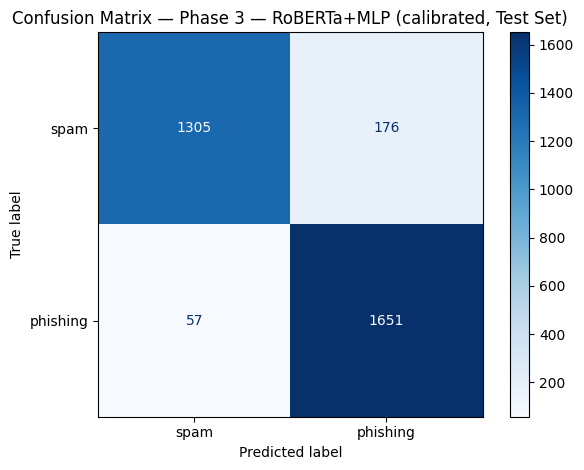

array([1, 0, 1, ..., 1, 1, 1], shape=(3189,))

In [9]:


# ── CELL 9: Evaluate ──────────────────────────────────────────────────────────
def evaluate(y_true, proba, name):
    pred = (proba >= 0.5).astype(int)
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(classification_report(y_true, pred, target_names=["spam", "phishing"], digits=4))
    print(f"ROC-AUC:   {roc_auc_score(y_true, proba):.4f}")
    print(f"PR-AUC:    {average_precision_score(y_true, proba):.4f}")
    print(f"Brier:     {brier_score_loss(y_true, proba):.4f}")
    cm = confusion_matrix(y_true, pred)
    ConfusionMatrixDisplay(cm, display_labels=["spam", "phishing"]).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout(); plt.show()
    return pred

evaluate(y_test, test_proba_p3_cal, "Phase 3 — RoBERTa+MLP (calibrated, Test Set)")



ECE (Phase 3, calibrated): 0.3889  (target < 0.05)


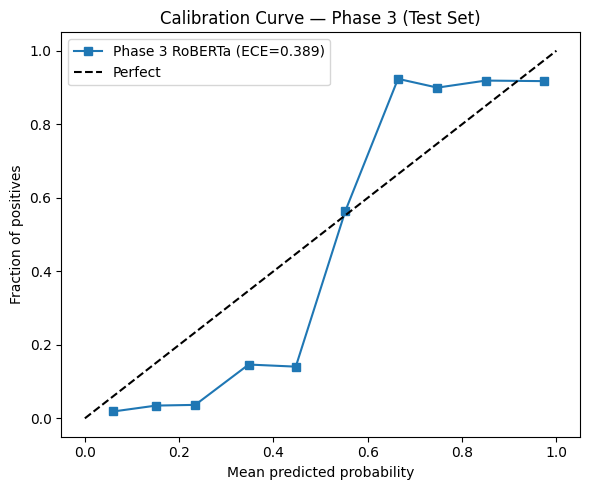

In [10]:

# ── CELL 10: ECE + calibration curve ─────────────────────────────────────────
def compute_ece(y_true, proba, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (proba >= bin_edges[i]) & (proba < bin_edges[i+1])
        if mask.sum() == 0:
            continue
        acc  = (y_true[mask] == (proba[mask] >= 0.5).astype(int)).mean()
        conf = proba[mask].mean()
        ece += mask.mean() * abs(acc - conf)
    return ece

ece_p3 = compute_ece(y_test, test_proba_p3_cal)
print(f"ECE (Phase 3, calibrated): {ece_p3:.4f}  (target < 0.05)")

prob_true, prob_pred = calibration_curve(y_test, test_proba_p3_cal, n_bins=10)
plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, "s-", label=f"Phase 3 RoBERTa (ECE={ece_p3:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction of positives")
plt.title("Calibration Curve — Phase 3 (Test Set)")
plt.legend(); plt.tight_layout(); plt.show()


In [11]:

# ── CELL 11: Routing simulation ───────────────────────────────────────────────
def trust_score(p, w1=0.6, w2=0.4):
    return (w1 * np.maximum(p, 1-p) + w2 * np.abs(2*p - 1)) * 100

scores = trust_score(test_proba_p3_cal)
bands = [
    ("auto_classify",         scores > 90),
    ("auto_classify_monitor", (scores > 75) & (scores <= 90)),
    ("analyst_review",        (scores > 55) & (scores <= 75)),
    ("priority_review",       scores <= 55),
]

print("\n=== ROUTING BAND ANALYSIS — Phase 3 ===")
print(f"{'Band':<28} {'Count':>6} {'%Total':>7} {'Ph.Recall':>10} {'FN Rate':>8}")
print("-" * 65)
total = len(y_test)
for band_name, mask in bands:
    if mask.sum() == 0:
        continue
    band_true = y_test[mask]
    band_pred = (test_proba_p3_cal[mask] >= 0.5).astype(int)
    ph_in_band = (band_true == 1).sum()
    fn_in_band = ((band_true == 1) & (band_pred == 0)).sum()
    ph_recall  = recall_score(band_true, band_pred, pos_label=1, zero_division=0) if ph_in_band > 0 else float("nan")
    fn_rate    = fn_in_band / ph_in_band if ph_in_band > 0 else 0.0
    print(f"{band_name:<28} {mask.sum():>6} {mask.sum()/total*100:>6.1f}%  {ph_recall:>9.4f}  {fn_rate:>7.4f}")

auto_mask = scores > 75
print(f"\nAuto-classified: {auto_mask.sum()} / {total} ({auto_mask.mean()*100:.1f}%)")
print(f"Phishing recall (auto only): {recall_score(y_test[auto_mask], (test_proba_p3_cal[auto_mask] >= 0.5).astype(int), pos_label=1):.4f}")




=== ROUTING BAND ANALYSIS — Phase 3 ===
Band                          Count  %Total  Ph.Recall  FN Rate
-----------------------------------------------------------------
auto_classify                  1164   36.5%     0.9964   0.0036
auto_classify_monitor           863   27.1%     0.9483   0.0517
analyst_review                  853   26.7%     0.9542   0.0458
priority_review                 309    9.7%     0.8820   0.1180

Auto-classified: 2027 / 3189 (63.6%)
Phishing recall (auto only): 0.9821


In [12]:

# ── CELL 13: Save model ───────────────────────────────────────────────────────
import pickle

OUT_DIR = Path("/kaggle/working")

# Save model weights
core = model_p3.module if hasattr(model_p3, "module") else model_p3
torch.save(core.state_dict(), OUT_DIR / "roberta_hybrid_phase3.pt")

# Save calibration temperature
with open(OUT_DIR / "phase3_temperature.pkl", "wb") as f:
    pickle.dump({"T": T_opt}, f)

print(f"Model saved to {OUT_DIR}/roberta_hybrid_phase3.pt")
print(f"Temperature T={T_opt:.4f} saved.")
print(f"\n=== PHASE 3 FINAL METRICS ===")
pred_final = (test_proba_p3_cal >= 0.5).astype(int)
print(f"Accuracy:           {accuracy_score(y_test, pred_final):.4f}")
print(f"Phishing Recall:    {recall_score(y_test, pred_final, pos_label=1):.4f}  (target > 0.98)")
print(f"Phishing Precision: {precision_score(y_test, pred_final, pos_label=1):.4f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, test_proba_p3_cal):.4f}")
print(f"Brier Score:        {brier_score_loss(y_test, test_proba_p3_cal):.4f}")
print(f"ECE:                {ece_p3:.4f}  (target < 0.05)")
auto_mask = trust_score(test_proba_p3_cal) > 75
print(f"Auto-classify rate: {auto_mask.mean()*100:.1f}%")
print(f"Ph. recall (auto):  {recall_score(y_test[auto_mask], pred_final[auto_mask], pos_label=1):.4f}")


Model saved to /kaggle/working/roberta_hybrid_phase3.pt
Temperature T=0.8562 saved.

=== PHASE 3 FINAL METRICS ===
Accuracy:           0.9269
Phishing Recall:    0.9666  (target > 0.98)
Phishing Precision: 0.9037
ROC-AUC:            0.9365
Brier Score:        0.0812
ECE:                0.3889  (target < 0.05)
Auto-classify rate: 63.6%
Ph. recall (auto):  0.9821
